# Is September really gold's best month? 🪙📅
### The oldest calendar story on the gold desk — a real physical mechanism, and no price edge to show for it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gold's_best_month%3F: Busted](https://img.shields.io/badge/Gold's_best_month%3F-Busted-8b949e?style=flat-square)

Every August you'll read some version of it: *"gold loves September"* — Indian wedding season is starting, Diwali shoppers are stocking up on jewellery months ahead, and jewellers everywhere restock before the year-end holidays. Meanwhile summer is supposedly dead — nobody's buying gold rings in July. It's a story with a real mechanism behind it: Indian households really do buy an enormous amount of physical gold around the autumn festivals.

The question this study asks is narrower and more useful: does any of that physical demand actually show up as a **price edge** in the gold you can buy on a US exchange? We tested 21+ years of GLD (SPDR Gold Shares) to find out.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the bootstrap CI? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    GLD, IRX = data.load_real()
    RET = st.monthly_log_returns(GLD)
    CASH = st.monthly_cash_return(IRX)
else:
    GLD = IRX = RET = CASH = None
print("real cache present:", HAVE_REAL, "| monthly observations:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-11-18', 'end': '2026-06-30', 'n_months': 259, 'bonferroni_crit': 2.89, 'month': {1: (3.47, 22, 3.22, 3.77), 2: (1.21, 22, 1.19, 1.52), 3: (-0.08, 22, -0.08, -0.08), 4: (1.57, 22, 1.66, 1.98), 5: (-0.54, 22, -0.63, -0.55), 6: (-0.85, 22, -0.72, -0.99), 7: (1.15, 21, 1.23, 1.65), 8: (1.47, 21, 1.49, 1.35), 9: (0.03, 21, 0.02, 0.02), 10: (0.64, 21, 0.56, 0.74), 11: (0.94, 21, 0.75, 0.62), 12: (0.71, 22, 0.72, 0.65)}, 'n_bonferroni_survive': 1, 'best_month': 1, 'best_mean': 3.47, 'best_t': 3.77, 'sep_mean': 0.03, 'sep_rest_mean': 0.88, 'sep_n': 21, 'sep_rest_n': 238, 'sep_spread': -0.85, 'sep_t': -0.64, 'sep_ci_lo': -3.23, 'sep_ci_hi': 1.6, 'sum_mean': 0.29, 'sum_rest_mean': 1.07, 'sum_n': 86, 'sum_rest_n': 173, 'sum_spread': -0.79, 'sum_t': -1.24, 'era_split': '2013-04-01', 'era_early': 2.49, 'era_early_n': 8, 'era_early_t': 0.53, 'era_late': -1.48, 'era_late_n': 13, 'era_late_t': -1.6, 'era_diff_t': -1.4, 'bh_sharpe': 0.47, 'bh_cagr': 8.59, 'bh_vol': 17.1, 'bh_maxdd': -46.7, 'bh_n': 259, 'timer_gross_sharpe': -0.02, 'timer_gross_cagr': 1.48, 'timer_vol': 5.8, 'timer_maxdd': -28.6, 'timer_net5_sharpe': -0.04, 'timer_net5_cagr': 1.38, 'timer_net10_sharpe': -0.05, 'timer_net10_cagr': 1.28, 'sep_hit': 9, 'sep_hit_n': 21, 'sep_hit_pct': 42.9, 'sep_hit_lo': 24.5, 'sep_hit_hi': 63.5, 'syn_null_mean': -0.31, 'syn_null_sd': 1.08, 'syn_null_fire': 2, 'syn_planted_t': 6.58, 'fp_gld': '44f6ff1685e4', 'fp_irx': '03b833c2e7e3'}


real cache present: True | monthly observations: 259


## The answer first

| Question | Answer |
|---|---|
| Is September really gold's best month? | **No.** Its average monthly return over 21+ years is **+0.03%** — essentially zero, and slightly *below* the other 11 months' **+0.88%** average. |
| Is summer really a quiet lull? | **Only a little, and not certified.** Summer months average **+0.29%** — still positive, just a bit softer than the rest of the year, and not statistically distinguishable from noise. |
| So is *any* month special? | **One is — January**, at **+3.47%/month**, a genuinely large effect. But that's a *different* story than the one we set out to test, and this study doesn't chase it. |
| Could you trade the September idea anyway? | **You'd be much better off not trying.** Owning gold *only* in September earns **+1.4%/yr** net of costs — buying and holding gold the whole time earns **+8.6%/yr**. |

> The mechanism is real. The price pattern isn't.

## 1 · The claim

> *"Gold has a calendar. Indian wedding season and pre-Diwali jewellery buying pull physical demand into September, and Northern-hemisphere jewellers restock ahead of the holidays — that's why September is gold's best month. Summer, by contrast, is the dead season: nobody's shopping for gold jewellery in July."*

This isn't idle chart-reading — the World Gold Council tracks Indian gold demand quarterly, and it genuinely clusters around the spring Akshaya Tritiya festival and the autumn wedding-and-festival season. The mechanism is textbook supply and demand: real households, buying real jewellery, on a real calendar.

## 2 · So what?

If a September premium were real and reliable, it would be one of the easiest trades in finance: no options, no leverage, no forecasting skill required — just buy GLD before September and sell it after, every single year. Financial-media roundups and seasonality-chart vendors sell exactly this idea every autumn.

So we ask two things: does September actually outperform, on the real tape, once we test it properly — and if you built the obvious trade around it, would you actually come out ahead of just buying gold and holding it?

## 3 · How would we even know?

- **The tape.** 259 months of GLD, 2004-11-18 → 2026-06-30 — every calendar month gold has traded as a US ETF.
- **The comparison.** September's average monthly return vs the other 11 months, and — because a chart-watcher could cherry-pick *any* of the 12 months and call it "the" seasonal — every month gets tested, with a **Bonferroni** correction for looking at 12 of them at once.
- **The trade check.** Buy GLD only in September (the calendar is public years in advance — no crystal ball needed), hold cash otherwise, pay costs, compare to simply buying and holding.

## 4 · The teardown — let's actually look

**First, the whole calendar.** Average GLD monthly return for every one of the 12 months.

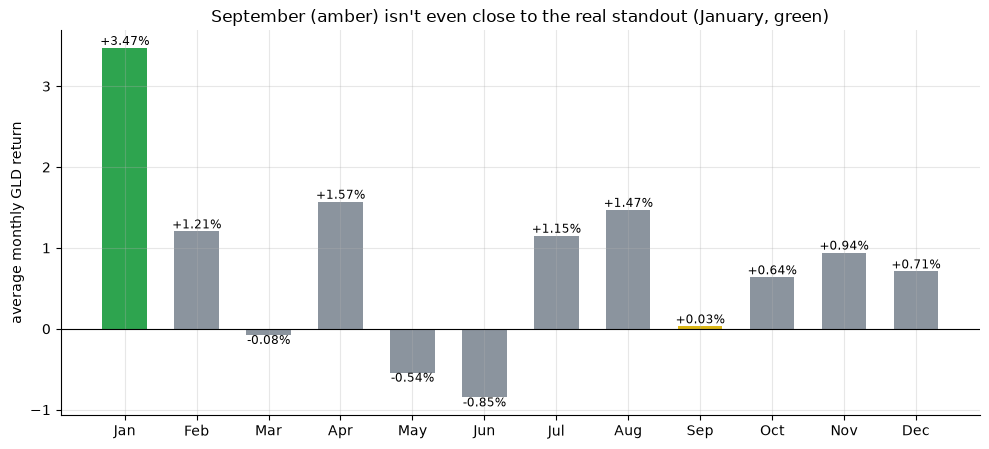

{'Jan': np.float64(3.47), 'Feb': np.float64(1.21), 'Mar': np.float64(-0.08), 'Apr': np.float64(1.57), 'May': np.float64(-0.54), 'Jun': np.float64(-0.85), 'Jul': np.float64(1.15), 'Aug': np.float64(1.47), 'Sep': np.float64(0.03), 'Oct': np.float64(0.64), 'Nov': np.float64(0.94), 'Dec': np.float64(0.71)}


In [2]:
if HAVE_REAL:
    ms = st.month_stats(RET)
    means = [ms.loc[m, 'mean'] * 100 for m in range(1, 13)]
else:
    means = [R['month'][m][0] for m in range(1, 13)]
names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig, ax = plt.subplots(figsize=(10.0, 4.6))
cols = [AMBER if m == 9 else (GREY if m != 1 else GREEN) for m in range(1, 13)]
ax.bar(names, means, color=cols, width=.62)
for i, v in enumerate(means): ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
    va='top' if v < 0 else 'bottom', fontsize=8.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average monthly GLD return')
ax.set_title("September (amber) isn't even close to the real standout (January, green)")
plt.tight_layout(); plt.show()
print({n: round(v, 2) for n, v in zip(names, means)})

September (amber) sits at **+0.03%** — dead in the middle of the pack. The genuine outlier is **January** (green), at **+3.47%/month** — a real effect statistically, but a completely different claim (a gold "January effect"), and not one this study set out to test or chase.

**Head-to-head:** September vs every other month, pooled.

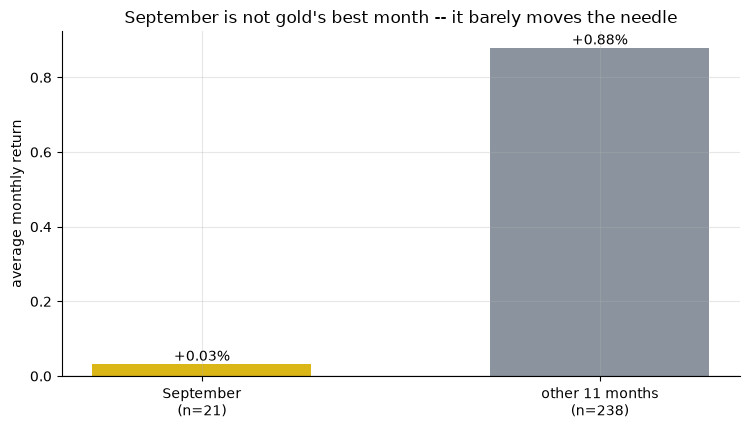

September +0.03%  vs  rest +0.88%


In [3]:
if HAVE_REAL:
    sep = st.month_vs_rest(RET, data.STRONG_MONTHS)
    sm, rm = sep['mean'], sep['rest_mean']
else:
    sm, rm = R['sep_mean']/100, R['sep_rest_mean']/100
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['September\n(n=21)', 'other 11 months\n(n=238)'], [sm*100, rm*100],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([sm*100, rm*100]): ax.annotate(f'{v:+.2f}%', (i, v),
    ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average monthly return')
ax.set_title('September is not gold\'s best month -- it barely moves the needle')
plt.tight_layout(); plt.show()
print(f'September {sm*100:+.2f}%  vs  rest {rm*100:+.2f}%')

September (**+0.03%**) is actually a touch *below* the other 11 months' average (**+0.88%**) — the wrong direction from the claim. The quants notebook shows this gap is nowhere near statistically real (Welch *t* = -0.64, need ±2 to even start taking it seriously).

**What about the "summer lull"?**

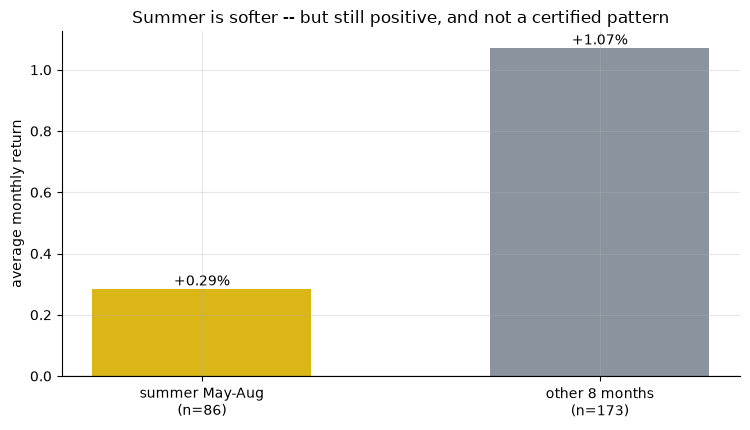

summer +0.29%  vs  rest +1.07%


In [4]:
if HAVE_REAL:
    summ = st.month_vs_rest(RET, data.SUMMER_MONTHS)
    a, b = summ['mean'], summ['rest_mean']
else:
    a, b = R['sum_mean']/100, R['sum_rest_mean']/100
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['summer May-Aug\n(n=86)', 'other 8 months\n(n=173)'], [a*100, b*100],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([a*100, b*100]): ax.annotate(f'{v:+.2f}%', (i, v),
    ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average monthly return')
ax.set_title('Summer is softer -- but still positive, and not a certified pattern')
plt.tight_layout(); plt.show()
print(f'summer {a*100:+.2f}%  vs  rest {b*100:+.2f}%')

Summer is a little softer (**+0.29%** vs **+1.07%** the rest of the year) — the right *direction* for the story, but gold still made money on average every summer, and the gap isn't statistically real either.

**Finally, the trade.** If you actually built the "own gold only in September" strategy, how would it have done against simply buying gold once and holding it?

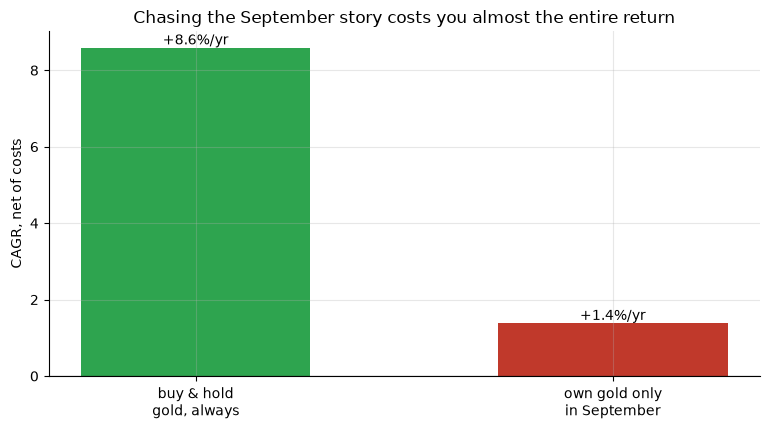

buy & hold +8.6%/yr   September-only timer (net) +1.4%/yr


In [5]:
if HAVE_REAL:
    bh = st.summary(RET, rf=CASH)
    timer = st.strong_month_timer(RET, data.STRONG_MONTHS, cash=CASH)
    net = st.apply_timer_costs(timer, data.STRONG_MONTHS, cost_bps_one_way=5.0)
    tn = st.summary(net, rf=CASH)
    bh_cagr, t_cagr = bh['cagr']*100, tn['cagr']*100
else:
    bh_cagr, t_cagr = R['bh_cagr'], R['timer_net5_cagr']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['buy & hold\ngold, always', 'own gold only\nin September'], [bh_cagr, t_cagr],
       color=[GREEN, RED], width=.55)
for i, v in enumerate([bh_cagr, t_cagr]): ax.annotate(f'{v:+.1f}%/yr', (i, v),
    ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('CAGR, net of costs')
ax.set_title('Chasing the September story costs you almost the entire return')
plt.tight_layout(); plt.show()
print(f'buy & hold {bh_cagr:+.1f}%/yr   September-only timer (net) {t_cagr:+.1f}%/yr')

Buying gold once and holding it earned **+8.6%/yr**. Trying to be clever and own it *only* in September earned **+1.4%/yr net** — you'd have given up nearly the entire two-decade gold bull market to sit in cash 11 months a year, waiting for a month that, on this tape, wasn't even special.

## 5 · The verdict

- **Signal — None.** September's average monthly return is statistically indistinguishable from an average month — and points the wrong direction. No month clears our multiple-testing bar in September's favor; the one that does (January) is a different story we didn't set out to tell.
- **Tradability — Mirage.** A strategy built around the September idea loses almost all of gold's return relative to simply buying and holding it.
- **"Gold's best month"? — Busted.** The physical-demand mechanism is real. The price pattern, on the ETF you can actually buy, is not.

## 6 · Going further 🚪

- **Physical demand ≠ price seasonality.** India's gold buying really does cluster seasonally — but gold's *price* is set by a much larger, dollar-denominated global futures/ETF-flow market, which can absorb a predictable regional demand pulse without leaving a systematic footprint in the return series.
- **January was the actual surprise here.** A genuinely large, statistically robust monthly effect — just not the one we were asked to test. A dedicated gold "January effect" study, done with the same discipline (Bonferroni, bootstrap, out-of-sample era split), would be the natural next study.
- **Sibling studies:** [289-diwali-muhurat](../../289-diwali-muhurat/) tests the same festival's *equity* omen in India; [69-safe-haven](../../69-safe-haven/) tests gold's inflation/crash-hedge behavior; neither touches gold's monthly calendar.

*Think there's a cleaner version of the seasonal story — maybe centered on the actual Diwali date, or on ETF flows rather than price? Show a net, certifiable edge after costs, and we'll take a look.*